# Exercise 1: CIFAR-10 Classification with CNN

## Author: A.N.R

In [17]:
!pip install torch torchvision matplotlib tqdm
!pip install "numpy<2.0" --upgrade
!pip install scikit-learn
!pip install seaborn

  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Obtaining dependency information for pandas>=1.2 from https://files.pythonhosted.org/packages/bf/c9/63f8d545568d9ab91476b1818b4741f521646cbdd151c6efebf40d6de6f7/pandas-2.3.3-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata
  Using cached pandas-2.3.3-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Obtaining dependency information for pytz>=2020.1 from https://files.pythonhosted.org/packages/81/c4/34e93fe5f5429d7570ec1fa436f1986fb1f00c3e0f43a589fe2bbcd22c3f/pytz-2025.2-py2.py3-none-any.whl.metadata
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached pandas-2.3.3-cp311-cp311-manylinux_2_24_x86_64.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms, datasets
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import time

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Loading and Preprocessing Data

In [3]:
# Define transforms
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Dataset path
data_path = './cifar10/cifar10'

# Load dataset
full_train_dataset = datasets.ImageFolder(root=os.path.join(data_path, 'train'), 
                                          transform=train_transform)
test_dataset = datasets.ImageFolder(root=os.path.join(data_path, 'test'), 
                                   transform=test_transform)

# Split train into train and validation
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

print(f'Training samples: {len(train_dataset)}')
print(f'Validation samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')
print(f'Classes: {full_train_dataset.classes}')

Training samples: 45000
Validation samples: 5000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## CNN Architecture Design

In [4]:
class CIFAR10_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CIFAR10_CNN, self).__init__()
        
        # Conv Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        
        # Conv Block 2
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.relu3 = nn.ReLU()
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.relu4 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout2 = nn.Dropout(0.25)
        
        # Conv Block 3
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.relu5 = nn.ReLU()
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.relu6 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)
        self.dropout3 = nn.Dropout(0.25)
        
        # Fully Connected Layers
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.relu7 = nn.ReLU()
        self.dropout4 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool1(x)
        x = self.dropout1(x)
        
        # Block 2
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu4(x)
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # Block 3
        x = self.conv5(x)
        x = self.bn5(x)
        x = self.relu5(x)
        x = self.conv6(x)
        x = self.bn6(x)
        x = self.relu6(x)
        x = self.pool3(x)
        x = self.dropout3(x)
        
        # FC layers
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu7(x)
        x = self.dropout4(x)
        x = self.fc2(x)
        
        return x

# Create a model instance for checking
model = CIFAR10_CNN().to(device)
print(model)

# Calculate number of parameters
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

CIFAR10_CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu4): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.25, inpla

## Training and Evaluation Functions

In [5]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in tqdm(dataloader, desc='Training'):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Validation'):
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    
    best_val_acc = 0.0
    
    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 50)
        
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            print(f'New best model! Val Acc: {val_acc:.4f}')
    
    return train_losses, train_accs, val_losses, val_accs, best_val_acc

## Part (a): Training with Different Batch Sizes and Optimizers

In [6]:
# Different configurations for experiments
batch_sizes = [32, 64, 128]
optimizer_configs = [
    {'name': 'SGD', 'class': optim.SGD, 'params': {'lr': 0.01, 'momentum': 0.9}},
    {'name': 'Adam', 'class': optim.Adam, 'params': {'lr': 0.001}},
    {'name': 'RMSprop', 'class': optim.RMSprop, 'params': {'lr': 0.001}}
]

num_epochs = 20

# Store results from all experiments
results = []

print('Starting experiments with different combinations of batch size and optimizer...')
print('='*70)

Starting experiments with different combinations of batch size and optimizer...


In [7]:
# Loop over batch sizes and optimizers
experiment_num = 0
for batch_size in batch_sizes:
    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    for opt_config in optimizer_configs:
        experiment_num += 1
        print(f'\n\n*** Experiment {experiment_num}/9 ***')
        print(f'Batch Size: {batch_size}, Optimizer: {opt_config["name"]}')
        print('='*70)
        
        # Create new model
        model = CIFAR10_CNN().to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = opt_config['class'](model.parameters(), **opt_config['params'])
        
        # Train model
        start_time = time.time()
        train_losses, train_accs, val_losses, val_accs, best_val_acc = train_model(
            model, train_loader, val_loader, criterion, optimizer, num_epochs, device
        )
        training_time = time.time() - start_time
        
        # Save results
        results.append({
            'batch_size': batch_size,
            'optimizer': opt_config['name'],
            'train_losses': train_losses,
            'train_accs': train_accs,
            'val_losses': val_losses,
            'val_accs': val_accs,
            'best_val_acc': best_val_acc,
            'training_time': training_time,
            'model_state': model.state_dict()
        })
        
        print(f'\nTraining completed in {training_time/60:.2f} minutes')
        print(f'Best validation accuracy: {best_val_acc:.4f}')

print('\n\nAll experiments completed!')



*** Experiment 1/9 ***
Batch Size: 32, Optimizer: SGD

Epoch 1/20
--------------------------------------------------


Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:01<00:00, 124.91it/s]


Train Loss: 1.8349, Train Acc: 0.3109
Val Loss: 1.4864, Val Acc: 0.4316
New best model! Val Acc: 0.4316

Epoch 2/20
--------------------------------------------------


Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:00<00:00, 166.66it/s]


Train Loss: 1.4419, Train Acc: 0.4746
Val Loss: 1.1453, Val Acc: 0.5822
New best model! Val Acc: 0.5822

Epoch 3/20
--------------------------------------------------


...

Train Loss: 0.6203, Train Acc: 0.7892
Val Loss: 0.6591, Val Acc: 0.7848
New best model! Val Acc: 0.7848

Epoch 19/20
--------------------------------------------------


Validation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 47.88it/s]


Train Loss: 0.6043, Train Acc: 0.7977
Val Loss: 0.6542, Val Acc: 0.7878
New best model! Val Acc: 0.7878

Epoch 20/20
--------------------------------------------------


Validation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 48.04it/s]

Train Loss: 0.5902, Train Acc: 0.7998
Val Loss: 0.5424, Val Acc: 0.8178
New best model! Val Acc: 0.8178

Training completed in 3.07 minutes
Best validation accuracy: 0.8178


All experiments completed!


## Part (b): Selecting the Best Model

In [8]:
# Find the best model
best_idx = np.argmax([r['best_val_acc'] for r in results])
best_result = results[best_idx]

print('Best model:')
print(f"Batch Size: {best_result['batch_size']}")
print(f"Optimizer: {best_result['optimizer']}")
print(f"Best Validation Accuracy: {best_result['best_val_acc']:.4f}")
print(f"Training Time: {best_result['training_time']/60:.2f} minutes")

# Load the best model
best_model = CIFAR10_CNN().to(device)
best_model.load_state_dict(best_result['model_state'])

# Results comparison table
print('\n\nComplete results comparison:')
print('-'*80)
print(f"{'Batch Size':<12} {'Optimizer':<12} {'Best Val Acc':<15} {'Training Time (min)'}")
print('-'*80)
for r in results:
    print(f"{r['batch_size']:<12} {r['optimizer']:<12} {r['best_val_acc']:<15.4f} {r['training_time']/60:.2f}")
print('-'*80)

Best model:
Batch Size: 64
Optimizer: Adam
Best Validation Accuracy: 0.8392
Training Time: 3.21 minutes


Complete results comparison:
--------------------------------------------------------------------------------
Batch Size   Optimizer    Best Val Acc    Training Time (min)
--------------------------------------------------------------------------------
32           SGD          0.8378          3.68
32           Adam         0.8378          3.71
32           RMSprop      0.8248          3.66
64           SGD          0.8318          3.23
64           Adam         0.8392          3.21
64           RMSprop      0.8040          3.27
128          SGD          0.8120          3.09
128          Adam         0.8256          3.08
128          RMSprop      0.8178          3.07
--------------------------------------------------------------------------------


## Part (c): Visualizing Training Process and Analyzing Results

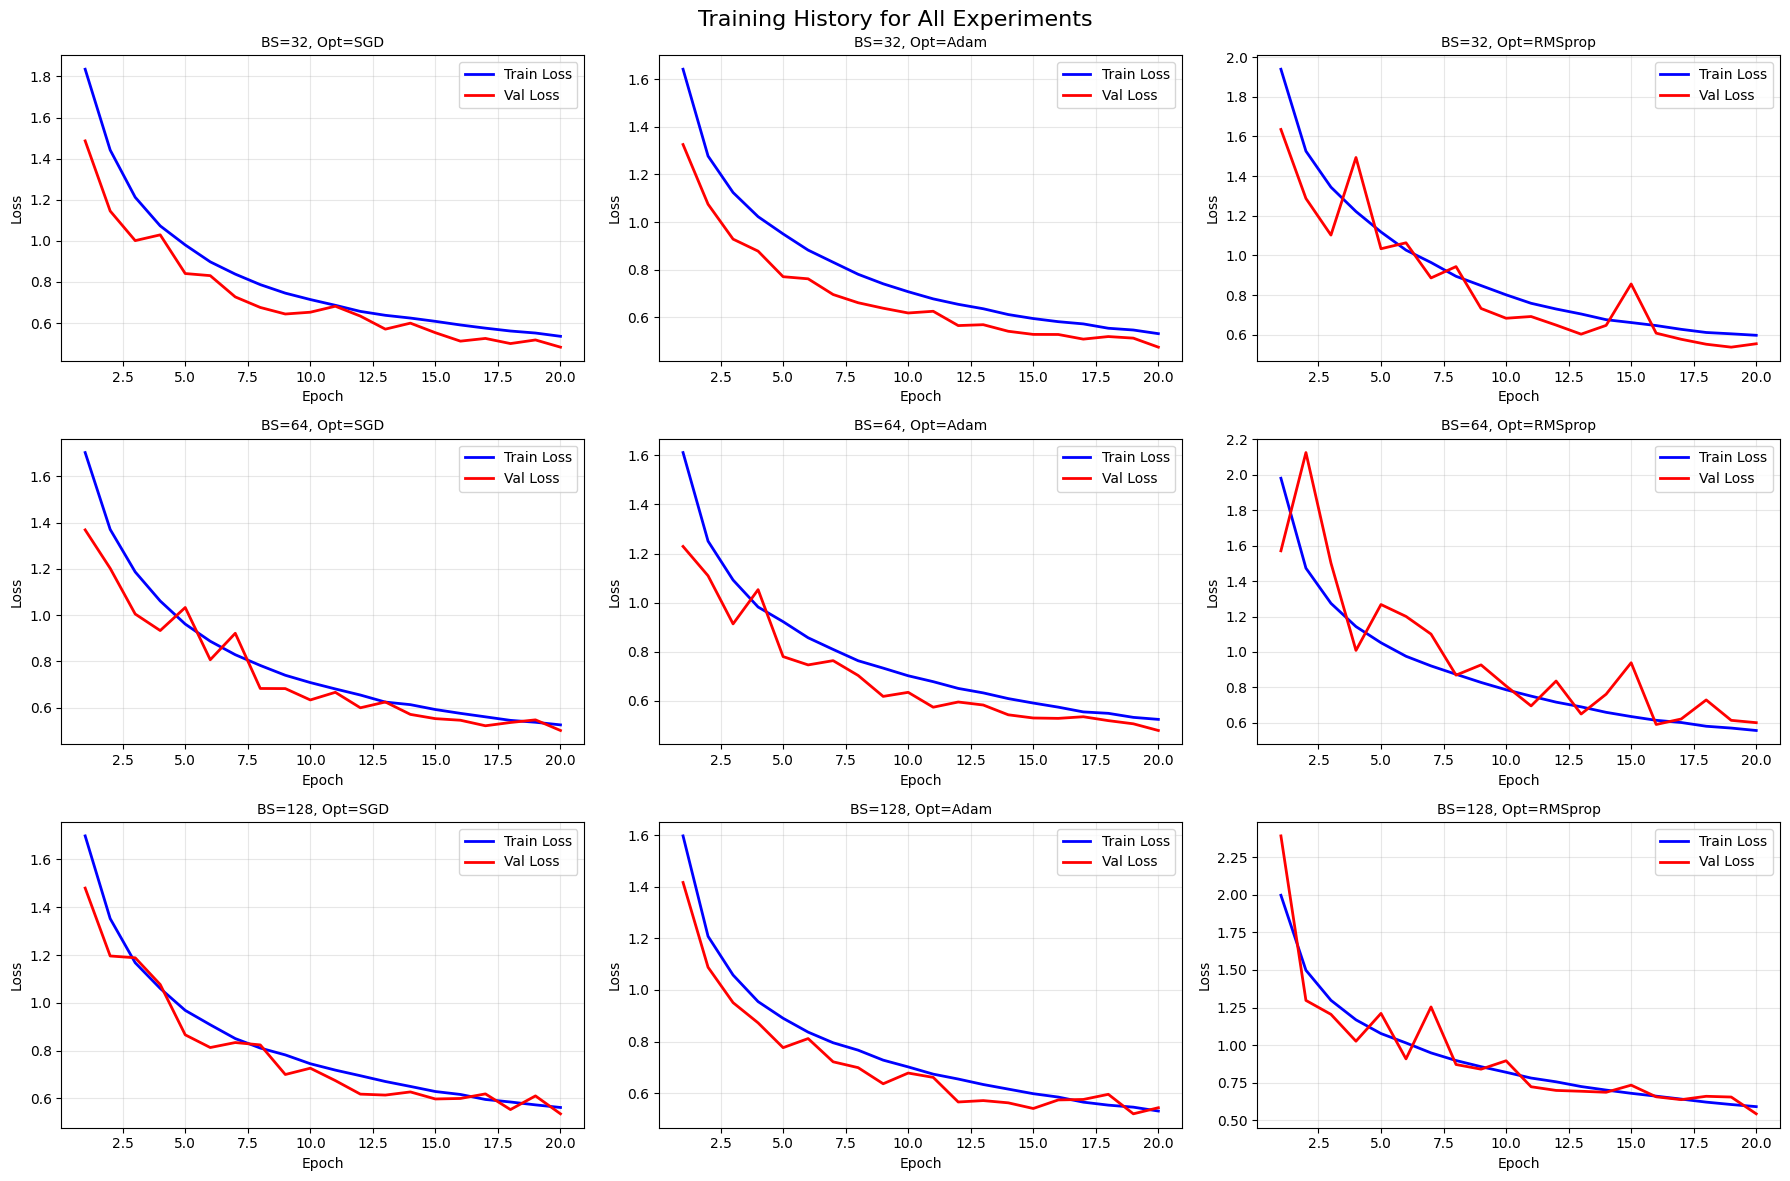

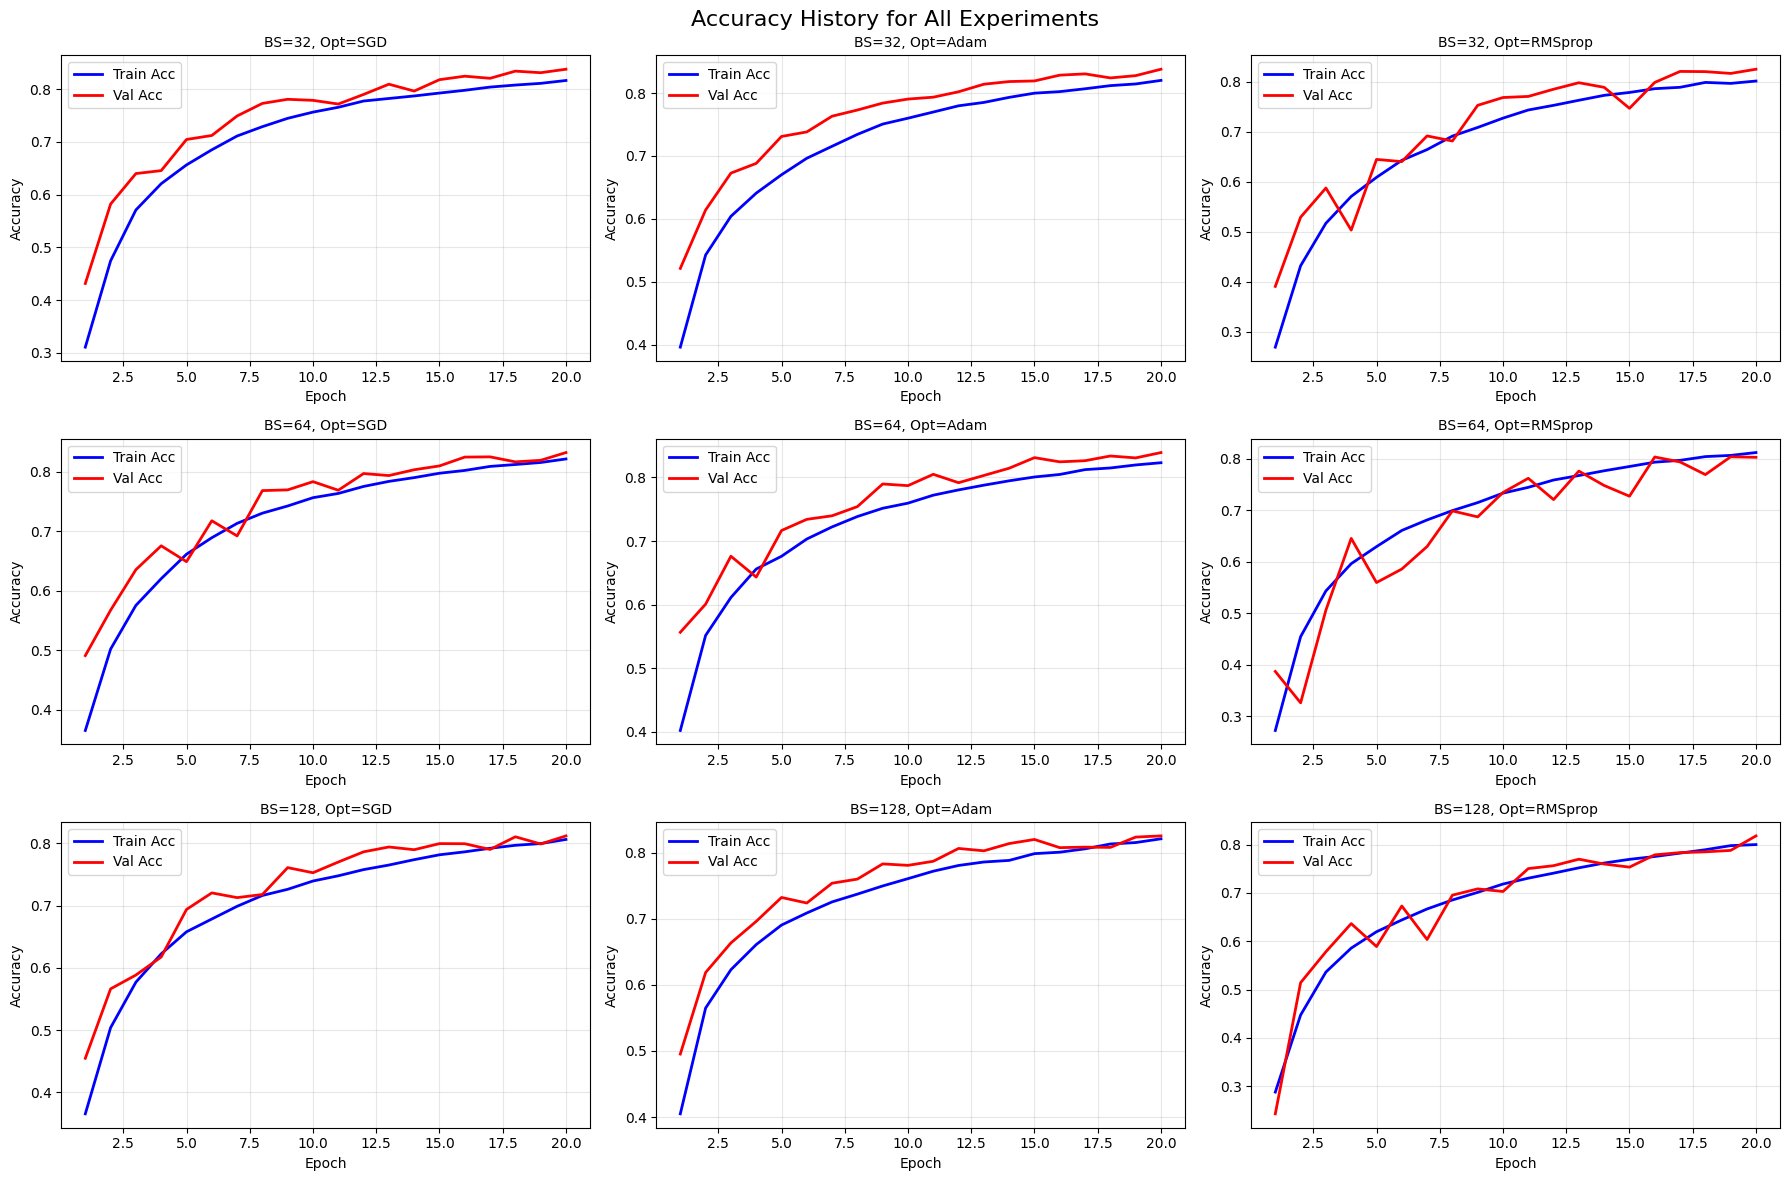

In [32]:
# Plot charts for all models
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Training History for All Experiments', fontsize=16)

for idx, result in enumerate(results):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    epochs_range = range(1, len(result['train_losses']) + 1)
    
    ax.plot(epochs_range, result['train_losses'], 'b-', label='Train Loss', linewidth=2)
    ax.plot(epochs_range, result['val_losses'], 'r-', label='Val Loss', linewidth=2)
    
    ax.set_title(f"BS={result['batch_size']}, Opt={result['optimizer']}", fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('all_experiments_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot accuracy charts
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Accuracy History for All Experiments', fontsize=16)

for idx, result in enumerate(results):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    epochs_range = range(1, len(result['train_accs']) + 1)
    
    ax.plot(epochs_range, result['train_accs'], 'b-', label='Train Acc', linewidth=2)
    ax.plot(epochs_range, result['val_accs'], 'r-', label='Val Acc', linewidth=2)
    
    ax.set_title(f"BS={result['batch_size']}, Opt={result['optimizer']}", fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('all_experiments_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

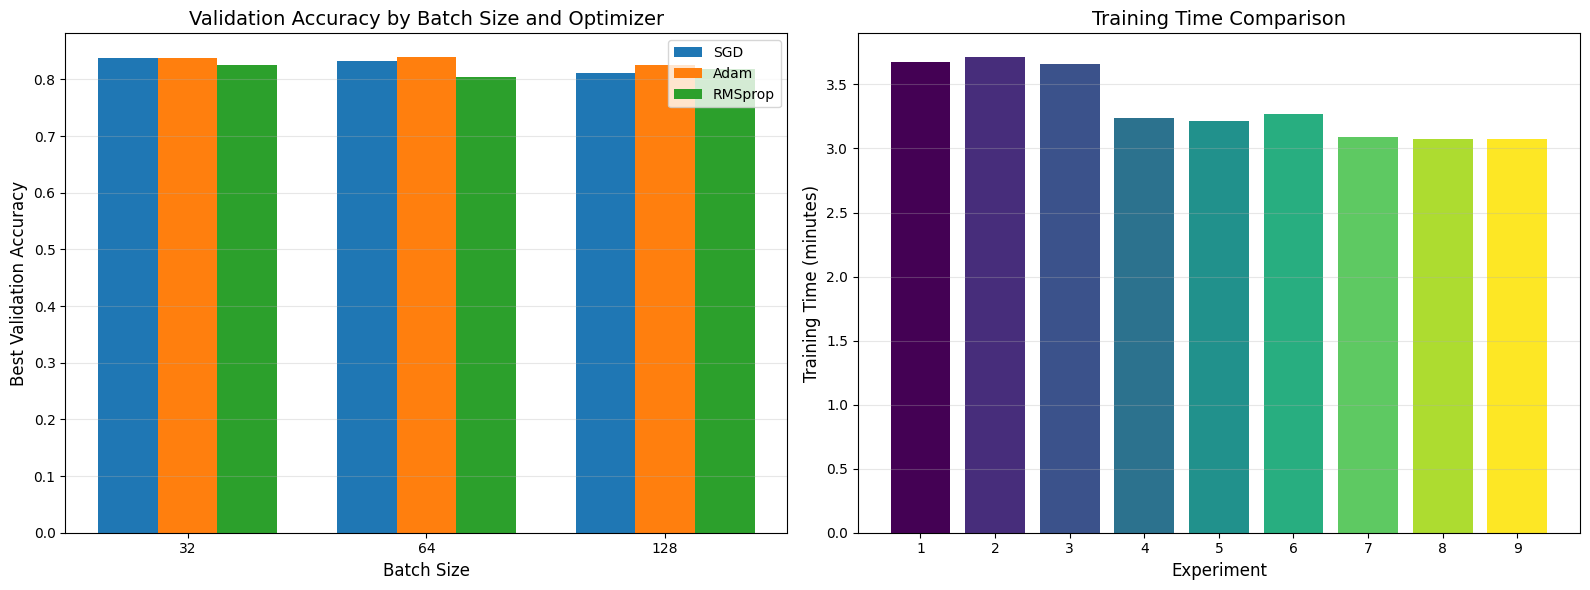

In [10]:
# Comparison chart of best validation accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of accuracy by batch size
batch_size_results = {}
for r in results:
    bs = r['batch_size']
    if bs not in batch_size_results:
        batch_size_results[bs] = []
    batch_size_results[bs].append(r['best_val_acc'])

x = np.arange(len(batch_sizes))
width = 0.25
for i, opt_name in enumerate(['SGD', 'Adam', 'RMSprop']):
    accs = [batch_size_results[bs][i] for bs in batch_sizes]
    ax1.bar(x + i*width, accs, width, label=opt_name)

ax1.set_xlabel('Batch Size', fontsize=12)
ax1.set_ylabel('Best Validation Accuracy', fontsize=12)
ax1.set_title('Validation Accuracy by Batch Size and Optimizer', fontsize=14)
ax1.set_xticks(x + width)
ax1.set_xticklabels(batch_sizes)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Training time chart
training_times = [r['training_time']/60 for r in results]
labels = [f"BS={r['batch_size']}\n{r['optimizer']}" for r in results]
colors = plt.cm.viridis(np.linspace(0, 1, len(results)))

ax2.bar(range(len(results)), training_times, color=colors)
ax2.set_xlabel('Experiment', fontsize=12)
ax2.set_ylabel('Training Time (minutes)', fontsize=12)
ax2.set_title('Training Time Comparison', fontsize=14)
ax2.set_xticks(range(len(results)))
ax2.set_xticklabels(range(1, len(results)+1))
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('comparison_charts.png', dpi=150, bbox_inches='tight')
plt.show()

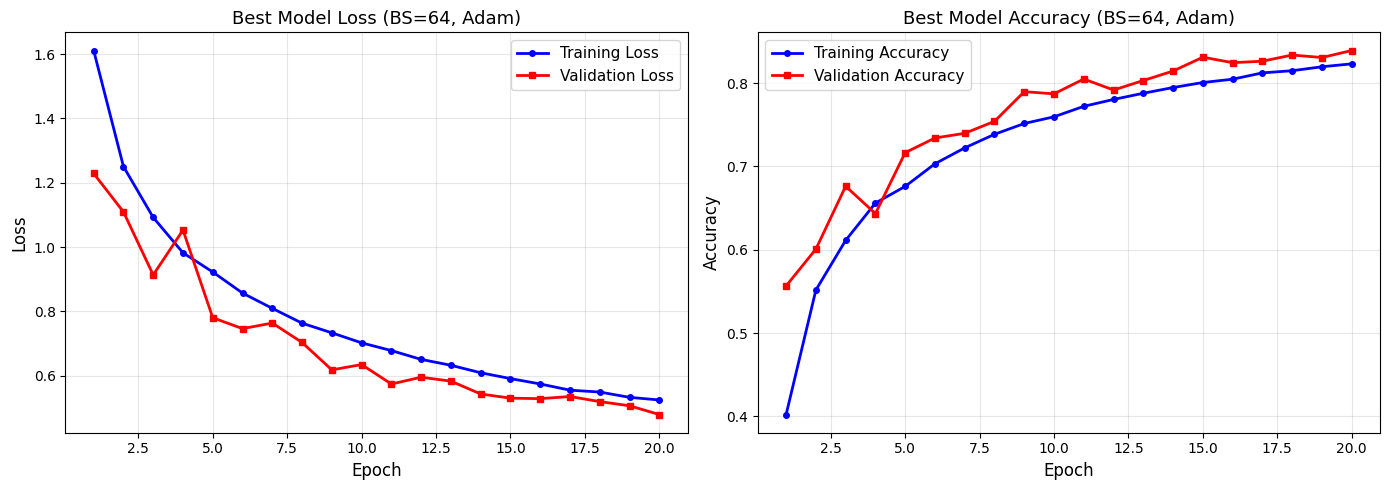

In [11]:
# Training and validation chart for best model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(best_result['train_losses']) + 1)

# Loss
ax1.plot(epochs_range, best_result['train_losses'], 'b-o', label='Training Loss', linewidth=2, markersize=4)
ax1.plot(epochs_range, best_result['val_losses'], 'r-s', label='Validation Loss', linewidth=2, markersize=4)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title(f"Best Model Loss (BS={best_result['batch_size']}, {best_result['optimizer']})", fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, best_result['train_accs'], 'b-o', label='Training Accuracy', linewidth=2, markersize=4)
ax2.plot(epochs_range, best_result['val_accs'], 'r-s', label='Validation Accuracy', linewidth=2, markersize=4)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title(f"Best Model Accuracy (BS={best_result['batch_size']}, {best_result['optimizer']})", fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('best_model_history.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluation on CIFAR-10 Test Data

In [15]:
# Evaluate best model on test set
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

best_model.eval()
test_correct = 0
test_total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc='Testing on CIFAR-10'):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = best_model(inputs)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = test_correct / test_total
print(f'\nCIFAR-10 Test Accuracy: {test_accuracy:.4f}')

Testing on CIFAR-10: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:01<00:00, 119.43it/s]


CIFAR-10 Test Accuracy: 0.8453


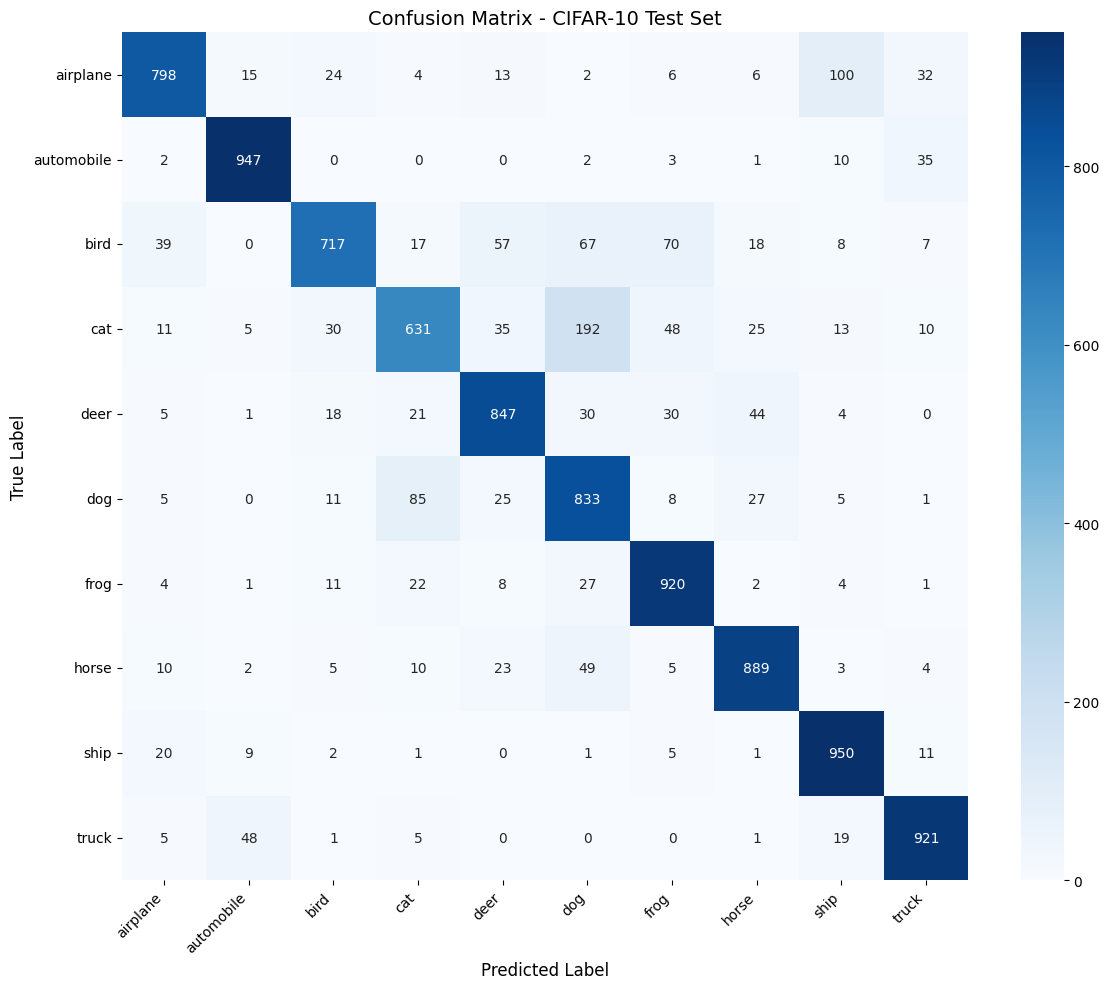


Classification Report:
              precision    recall  f1-score   support

    airplane       0.89      0.80      0.84      1000
  automobile       0.92      0.95      0.93      1000
        bird       0.88      0.72      0.79      1000
         cat       0.79      0.63      0.70      1000
        deer       0.84      0.85      0.84      1000
         dog       0.69      0.83      0.76      1000
        frog       0.84      0.92      0.88      1000
       horse       0.88      0.89      0.88      1000
        ship       0.85      0.95      0.90      1000
       truck       0.90      0.92      0.91      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.84     10000
weighted avg       0.85      0.85      0.84     10000



In [18]:
# Calculate and display confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - CIFAR-10 Test Set', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('cifar10_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Accuracy report for each class
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=class_names))

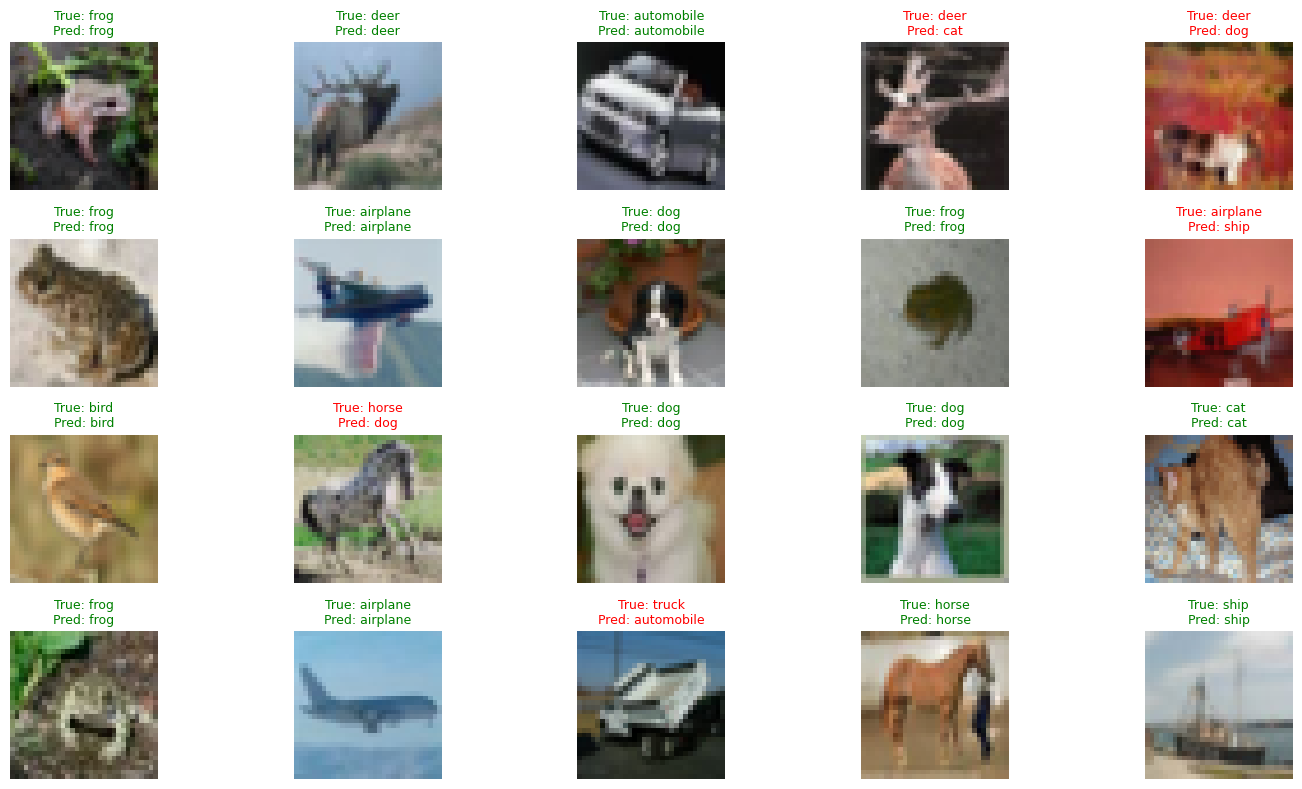

In [19]:
# Display some sample predictions
fig = plt.figure(figsize=(15, 8))
n_samples = 20

# Get some random samples
indices = np.random.choice(len(test_dataset), n_samples, replace=False)

best_model.eval()
with torch.no_grad():
    for i, idx in enumerate(indices):
        img, label = test_dataset[idx]
        img_display = img.cpu().numpy().transpose((1, 2, 0))
        # Denormalize
        mean = np.array([0.4914, 0.4822, 0.4465])
        std = np.array([0.2470, 0.2435, 0.2616])
        img_display = std * img_display + mean
        img_display = np.clip(img_display, 0, 1)
        
        output = best_model(img.unsqueeze(0).to(device))
        _, pred = torch.max(output, 1)
        pred_class = pred.item()
        
        ax = fig.add_subplot(4, 5, i+1)
        ax.imshow(img_display)
        ax.axis('off')
        
        color = 'green' if pred_class == label else 'red'
        ax.set_title(f'True: {class_names[label]}\nPred: {class_names[pred_class]}', 
                    fontsize=9, color=color)

plt.tight_layout()
plt.savefig('sample_predictions_cifar10.png', dpi=150, bbox_inches='tight')
plt.show()

## Part (d): Evaluation on MNIST and Comparison with CIFAR-10

In [20]:
# Load MNIST
mnist_transform = transforms.Compose([
    transforms.Resize((32, 32)),  # Resize to CIFAR-10 size
    transforms.Grayscale(3),  # Convert to 3 channels
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

mnist_test = torchvision.datasets.MNIST(root='./data', train=False, 
                                        download=True, transform=mnist_transform)
mnist_test_loader = DataLoader(mnist_test, batch_size=64, shuffle=False)

print(f'MNIST test samples: {len(mnist_test)}')

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:09<00:00, 1.03MB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 146kB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 2.39MB/s]

MNIST test samples: 10000


In [21]:
# Evaluate CIFAR-10 model on MNIST
best_model.eval()
mnist_correct = 0
mnist_total = 0
mnist_preds = []
mnist_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(mnist_test_loader, desc='Testing on MNIST'):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = best_model(inputs)
        _, predicted = torch.max(outputs, 1)
        mnist_total += labels.size(0)
        # For MNIST with 10 classes (0-9), we need to be careful that predictions are also between 0-9
        # But our model is trained for CIFAR-10 and has different classes
        
        mnist_preds.extend(predicted.cpu().numpy())
        mnist_labels.extend(labels.cpu().numpy())

print(f'\nTesting CIFAR-10 model on MNIST:')
print(f'Note: Model is trained for CIFAR-10 and has different classes.')
print(f'This evaluation is only for performance comparison.')

# نمایش توزیع پیش‌بینی‌ها
unique, counts = np.unique(mnist_preds, return_counts=True)
pred_dist = dict(zip(unique, counts))
print(f'\nModel prediction distribution on MNIST:')
for class_idx in range(10):
    count = pred_dist.get(class_idx, 0)
    print(f'Class {class_idx} ({class_names[class_idx]}): {count} predictions ({100*count/mnist_total:.2f}%)')

Testing on MNIST: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:01<00:00, 143.37it/s]


Testing CIFAR-10 model on MNIST:
Note: Model is trained for CIFAR-10 and has different classes.
This evaluation is only for performance comparison.

Model prediction distribution on MNIST:
Class 0 (airplane): 271 predictions (2.71%)
Class 1 (automobile): 39 predictions (0.39%)
Class 2 (bird): 8269 predictions (82.69%)
Class 3 (cat): 237 predictions (2.37%)
Class 4 (deer): 0 predictions (0.00%)
Class 5 (dog): 639 predictions (6.39%)
Class 6 (frog): 213 predictions (2.13%)
Class 7 (horse): 1 predictions (0.01%)
Class 8 (ship): 331 predictions (3.31%)
Class 9 (truck): 0 predictions (0.00%)


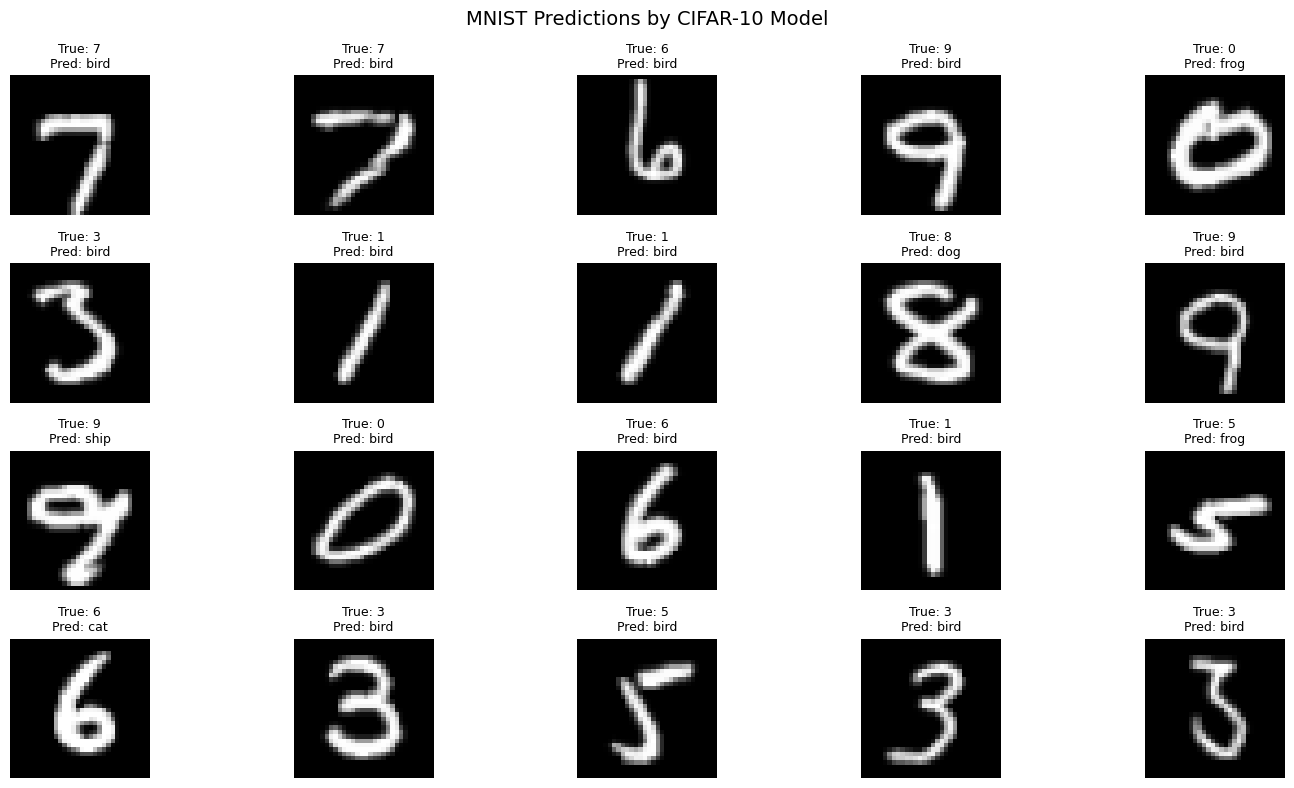

In [22]:
# Display some MNIST predictions
fig = plt.figure(figsize=(15, 8))
n_samples = 20

indices = np.random.choice(len(mnist_test), n_samples, replace=False)

best_model.eval()
with torch.no_grad():
    for i, idx in enumerate(indices):
        img, label = mnist_test[idx]
        img_display = img.cpu().numpy().transpose((1, 2, 0))
        # Denormalize
        img_display = img_display * 0.5 + 0.5
        img_display = np.clip(img_display, 0, 1)
        
        output = best_model(img.unsqueeze(0).to(device))
        _, pred = torch.max(output, 1)
        pred_class = pred.item()
        
        ax = fig.add_subplot(4, 5, i+1)
        ax.imshow(img_display[:,:,0], cmap='gray')
        ax.axis('off')
        ax.set_title(f'True: {label}\nPred: {class_names[pred_class]}', fontsize=9)

plt.suptitle('MNIST Predictions by CIFAR-10 Model', fontsize=14)
plt.tight_layout()
plt.savefig('mnist_predictions_cifar10_model.png', dpi=150, bbox_inches='tight')
plt.show()

## Part (e): Training Model with MNIST and Comparing Results

In [23]:
# Load MNIST for training
mnist_train_full = torchvision.datasets.MNIST(root='./data', train=True, 
                                               download=True, transform=mnist_transform)

# Split into train and validation
mnist_train_size = int(0.9 * len(mnist_train_full))
mnist_val_size = len(mnist_train_full) - mnist_train_size
mnist_train, mnist_val = random_split(mnist_train_full, [mnist_train_size, mnist_val_size])

print(f'MNIST Training samples: {len(mnist_train)}')
print(f'MNIST Validation samples: {len(mnist_val)}')
print(f'MNIST Test samples: {len(mnist_test)}')

MNIST Training samples: 54000
MNIST Validation samples: 6000
MNIST Test samples: 10000


In [24]:
# Create new model for MNIST (10 classes)
mnist_model = CIFAR10_CNN(num_classes=10).to(device)

# Use best combination of batch size and optimizer
mnist_batch_size = best_result['batch_size']
mnist_train_loader = DataLoader(mnist_train, batch_size=mnist_batch_size, shuffle=True)
mnist_val_loader = DataLoader(mnist_val, batch_size=mnist_batch_size, shuffle=False)

criterion = nn.CrossEntropyLoss()

# Create optimizer based on best settings
if best_result['optimizer'] == 'SGD':
    optimizer = optim.SGD(mnist_model.parameters(), lr=0.01, momentum=0.9)
elif best_result['optimizer'] == 'Adam':
    optimizer = optim.Adam(mnist_model.parameters(), lr=0.001)
else:  # RMSprop
    optimizer = optim.RMSprop(mnist_model.parameters(), lr=0.001)

print(f"Training MNIST model with: Batch Size={mnist_batch_size}, Optimizer={best_result['optimizer']}")

Training MNIST model with: Batch Size=64, Optimizer=Adam


In [25]:
# Train MNIST model
num_epochs_mnist = 15
start_time = time.time()

mnist_train_losses, mnist_train_accs, mnist_val_losses, mnist_val_accs, mnist_best_val_acc = train_model(
    mnist_model, mnist_train_loader, mnist_val_loader, criterion, optimizer, num_epochs_mnist, device
)

mnist_training_time = time.time() - start_time
print(f'\nMNIST training completed in {mnist_training_time/60:.2f} minutes')
print(f'Best MNIST validation accuracy: {mnist_best_val_acc:.4f}')


Epoch 1/15
--------------------------------------------------


Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 94/94 [00:00<00:00, 146.21it/s]


Train Loss: 0.1747, Train Acc: 0.9458
Val Loss: 0.0908, Val Acc: 0.9753
New best model! Val Acc: 0.9753

Epoch 2/15
--------------------------------------------------


Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 94/94 [00:00<00:00, 150.06it/s]


Train Loss: 0.0683, Train Acc: 0.9803
Val Loss: 0.0340, Val Acc: 0.9893
New best model! Val Acc: 0.9893

Epoch 3/15
--------------------------------------------------


...

Train Loss: 0.0203, Train Acc: 0.9940
Val Loss: 0.0243, Val Acc: 0.9935

Epoch 14/15
--------------------------------------------------


Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 94/94 [00:00<00:00, 149.56it/s]


Train Loss: 0.0180, Train Acc: 0.9943
Val Loss: 0.0228, Val Acc: 0.9940

Epoch 15/15
--------------------------------------------------


Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 94/94 [00:00<00:00, 150.82it/s]

Train Loss: 0.0182, Train Acc: 0.9944
Val Loss: 0.0316, Val Acc: 0.9920

MNIST training completed in 1.87 minutes
Best MNIST validation accuracy: 0.9947


In [26]:
# Evaluate MNIST model on test set
mnist_model.eval()
mnist_test_correct = 0
mnist_test_total = 0
mnist_test_preds = []
mnist_test_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(mnist_test_loader, desc='Testing MNIST Model'):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = mnist_model(inputs)
        _, predicted = torch.max(outputs, 1)
        mnist_test_total += labels.size(0)
        mnist_test_correct += (predicted == labels).sum().item()
        
        mnist_test_preds.extend(predicted.cpu().numpy())
        mnist_test_labels.extend(labels.cpu().numpy())

mnist_test_accuracy = mnist_test_correct / mnist_test_total
print(f'\nMNIST Test Accuracy: {mnist_test_accuracy:.4f}')

Testing MNIST Model: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:01<00:00, 147.04it/s]


MNIST Test Accuracy: 0.9944


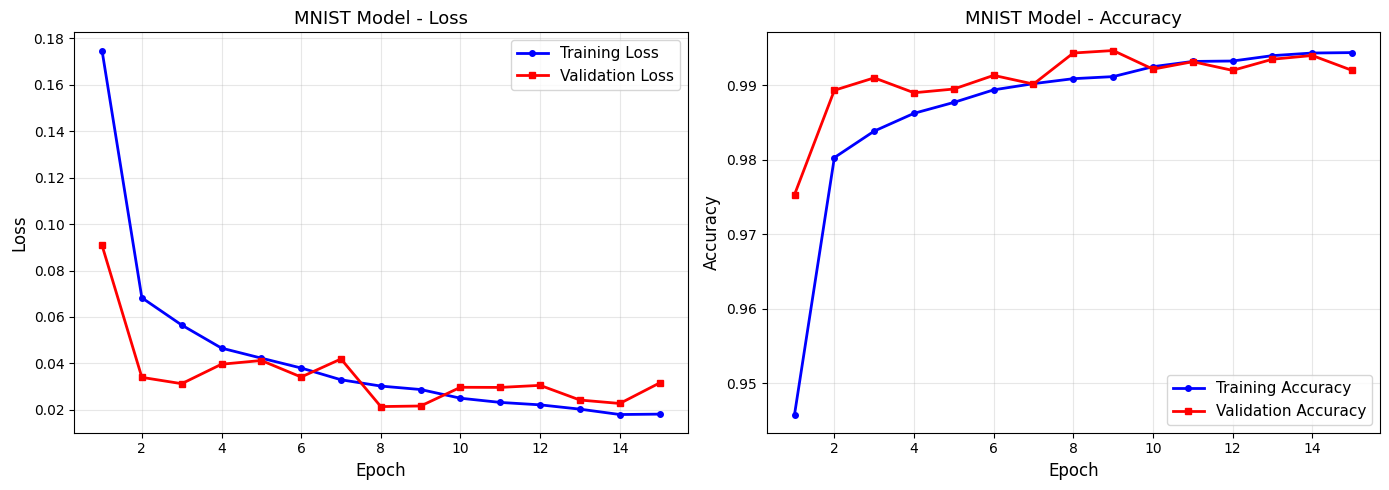

In [27]:
# Plot training charts for MNIST
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, num_epochs_mnist + 1)

# Loss
ax1.plot(epochs_range, mnist_train_losses, 'b-o', label='Training Loss', linewidth=2, markersize=4)
ax1.plot(epochs_range, mnist_val_losses, 'r-s', label='Validation Loss', linewidth=2, markersize=4)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('MNIST Model - Loss', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, mnist_train_accs, 'b-o', label='Training Accuracy', linewidth=2, markersize=4)
ax2.plot(epochs_range, mnist_val_accs, 'r-s', label='Validation Accuracy', linewidth=2, markersize=4)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('MNIST Model - Accuracy', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mnist_model_history.png', dpi=150, bbox_inches='tight')
plt.show()

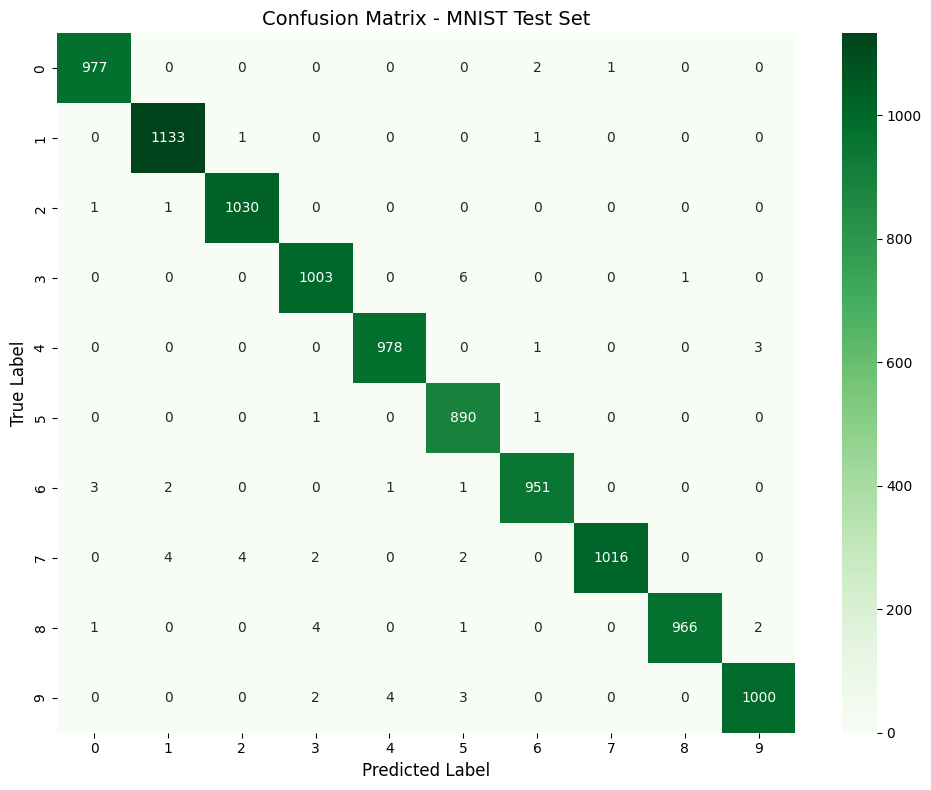


MNIST Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      1.00       982
           5       0.99      1.00      0.99       892
           6       0.99      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       1.00      0.99      1.00       974
           9       1.00      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [28]:
# Confusion matrix برای MNIST
mnist_cm = confusion_matrix(mnist_test_labels, mnist_test_preds)
mnist_classes = [str(i) for i in range(10)]

plt.figure(figsize=(10, 8))
sns.heatmap(mnist_cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=mnist_classes, yticklabels=mnist_classes)
plt.title('Confusion Matrix - MNIST Test Set', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('mnist_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMNIST Classification Report:')
print(classification_report(mnist_test_labels, mnist_test_preds, target_names=mnist_classes))

## Final Comparison of CIFAR-10 and MNIST


Final Comparison of CIFAR-10 and MNIST Results
 Dataset  Test Accuracy  Best Val Accuracy  Training Time (min)  Batch Size Optimizer
CIFAR-10         0.8453           0.839200             3.213366          64      Adam
   MNIST         0.9944           0.994667             1.867181          64      Adam


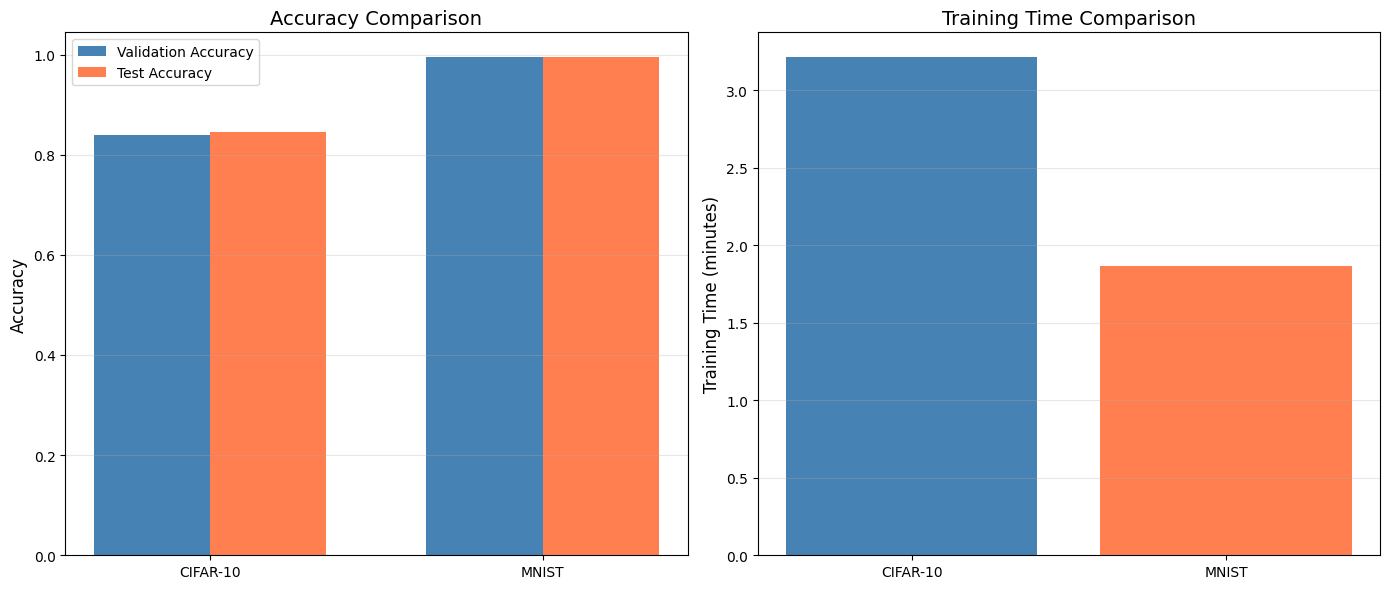

In [29]:
# Compare results
comparison_data = {
    'Dataset': ['CIFAR-10', 'MNIST'],
    'Test Accuracy': [test_accuracy, mnist_test_accuracy],
    'Best Val Accuracy': [best_result['best_val_acc'], mnist_best_val_acc],
    'Training Time (min)': [best_result['training_time']/60, mnist_training_time/60],
    'Batch Size': [best_result['batch_size'], mnist_batch_size],
    'Optimizer': [best_result['optimizer'], best_result['optimizer']]
}

import pandas as pd
df_comparison = pd.DataFrame(comparison_data)
print('\n' + '='*80)
print('Final Comparison of CIFAR-10 and MNIST Results')
print('='*80)
print(df_comparison.to_string(index=False))
print('='*80)

# Plot comparison chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy comparison
datasets = ['CIFAR-10', 'MNIST']
test_accs = [test_accuracy, mnist_test_accuracy]
val_accs = [best_result['best_val_acc'], mnist_best_val_acc]

x = np.arange(len(datasets))
width = 0.35

ax1.bar(x - width/2, val_accs, width, label='Validation Accuracy', color='steelblue')
ax1.bar(x + width/2, test_accs, width, label='Test Accuracy', color='coral')
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Accuracy Comparison', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(datasets)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Training time comparison
training_times = [best_result['training_time']/60, mnist_training_time/60]
ax2.bar(datasets, training_times, color=['steelblue', 'coral'])
ax2.set_ylabel('Training Time (minutes)', fontsize=12)
ax2.set_title('Training Time Comparison', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

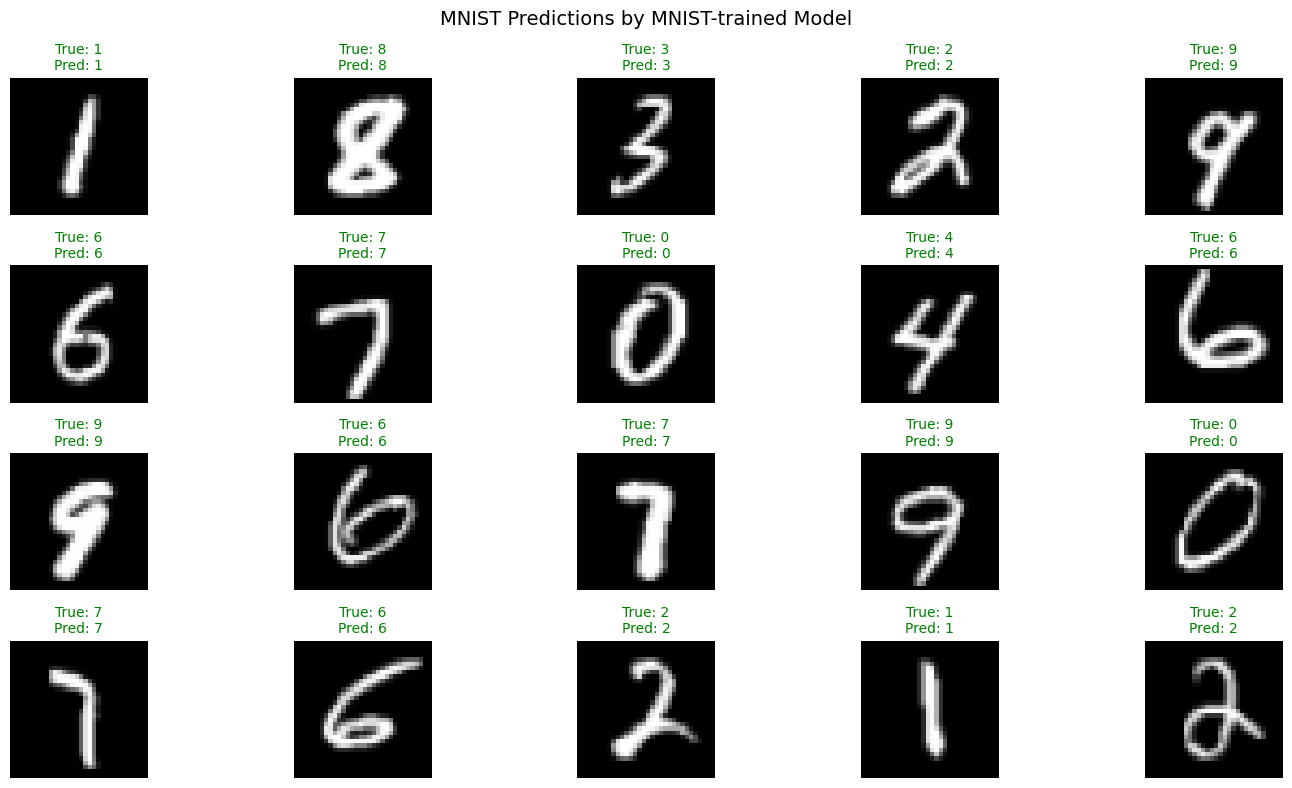

In [30]:
# Display samples from MNIST model predictions
fig = plt.figure(figsize=(15, 8))
n_samples = 20

indices = np.random.choice(len(mnist_test), n_samples, replace=False)

mnist_model.eval()
with torch.no_grad():
    for i, idx in enumerate(indices):
        img, label = mnist_test[idx]
        img_display = img.cpu().numpy().transpose((1, 2, 0))
        img_display = img_display * 0.5 + 0.5
        img_display = np.clip(img_display, 0, 1)
        
        output = mnist_model(img.unsqueeze(0).to(device))
        _, pred = torch.max(output, 1)
        pred_class = pred.item()
        
        ax = fig.add_subplot(4, 5, i+1)
        ax.imshow(img_display[:,:,0], cmap='gray')
        ax.axis('off')
        
        color = 'green' if pred_class == label else 'red'
        ax.set_title(f'True: {label}\nPred: {pred_class}', fontsize=10, color=color)

plt.suptitle('MNIST Predictions by MNIST-trained Model', fontsize=14)
plt.tight_layout()
plt.savefig('mnist_predictions_mnist_model.png', dpi=150, bbox_inches='tight')
plt.show()

## Saving Models

In [31]:
# Save best CIFAR-10 model
torch.save({
    'model_state_dict': best_model.state_dict(),
    'batch_size': best_result['batch_size'],
    'optimizer': best_result['optimizer'],
    'val_acc': best_result['best_val_acc'],
    'test_acc': test_accuracy
}, 'best_cifar10_model.pth')

# Save MNIST model
torch.save({
    'model_state_dict': mnist_model.state_dict(),
    'batch_size': mnist_batch_size,
    'optimizer': best_result['optimizer'],
    'val_acc': mnist_best_val_acc,
    'test_acc': mnist_test_accuracy
}, 'mnist_model.pth')

print('Models saved successfully!')
print('- best_cifar10_model.pth')
print('- mnist_model.pth')

Models saved successfully!
- best_cifar10_model.pth
- mnist_model.pth
